<a href="https://colab.research.google.com/github/kishmish07/ml_analytics-journey/blob/main/project_online_retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [78]:
import pandas as pd
data = pd.read_csv('data.csv',encoding='cp1251')

In [79]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Как видим много пропущенных значений в столбцу CustomerID и есть пропущенные значения в столбце Description.Принимаю решение удалить все строки которые имеют значение Null.В таком случае получим 75% чистых данных и около 400к+ данных,что достаточно для обучения модели



In [81]:
data = data.dropna()

In [82]:
data['TotalPrice'] = data['UnitPrice'] * data['Quantity']

In [83]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [84]:
data_country_revenue = data.groupby('Country')['TotalPrice'].sum().reset_index()
data_country_revenue = data_country_revenue.sort_values('TotalPrice',ascending=False)
data_country_revenue

,Country,TotalPrice
35,United Kingdom,6767873.394
23,Netherlands,284661.540
10,EIRE,250285.220
14,Germany,221698.210
13,France,196712.840
0,Australia,137077.270
32,Switzerland,55739.400
30,Spain,54774.580
3,Belgium,40910.960
31,Sweden,36595.910


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'United Kingdom'),
  Text(1, 0, 'Netherlands'),
  Text(2, 0, 'EIRE'),
  Text(3, 0, 'Germany'),
  Text(4, 0, 'France'),
  Text(5, 0, 'Australia'),
  Text(6, 0, 'Switzerland'),
  Text(7, 0, 'Spain'),
  Text(8, 0, 'Belgium'),
  Text(9, 0, 'Sweden')])

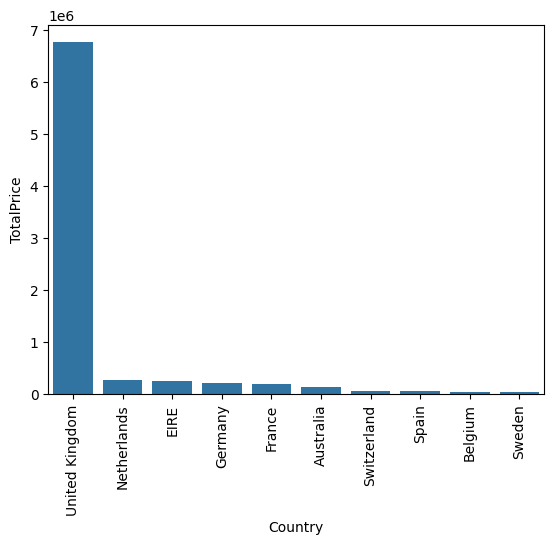

In [85]:
sns.barplot(x = 'Country',y = 'TotalPrice',data = data_country_revenue.iloc[:10])
plt.xticks(rotation=90)

Как видно из графика,то на большую сумму товаров купили из Великобритании,из чего можно сделать вывод что онлайн сервис из Англии.Вторая по покупкам страна - Нидерланды,чьи заказы практически в 13 раз меньше.

In [88]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [90]:
data['Month'] = data['InvoiceDate'].dt.month

In [101]:
data_month = data.groupby('Month')['Quantity'].sum()
data_month = data_month.to_frame()

<Axes: xlabel='Month', ylabel='Quantity'>

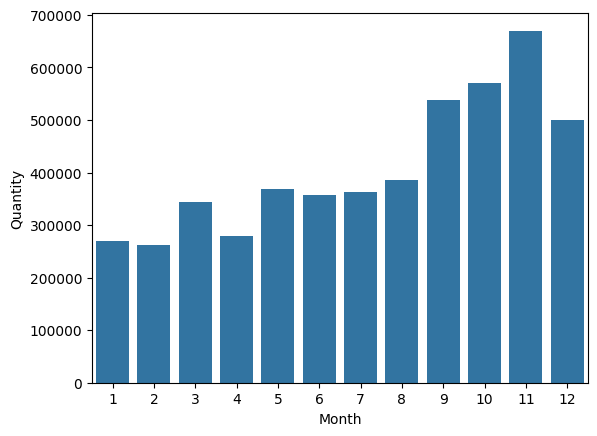

In [102]:
sns.barplot(x='Month',y = 'Quantity',data = data_month)

Можем увидеть что больше всего заказов приходится на сезон осень

<Axes: xlabel='InvoiceDate', ylabel='Quantity'>

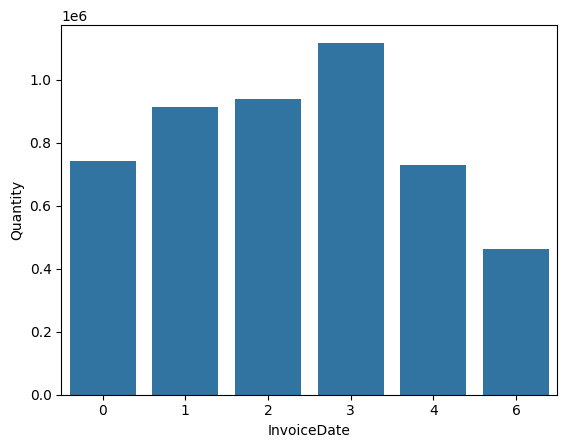

In [104]:
data_week = data.groupby(data['InvoiceDate'].dt.dayofweek)['Quantity'].sum()
data_week = data_week.to_frame()
sns.barplot(x= 'InvoiceDate',y='Quantity',data =  data_week)

Можем заметить что наибольшее количество заказов приходится на пятницу,в выходные количество заказов наименьшее

<Axes: xlabel='InvoiceDate', ylabel='Quantity'>

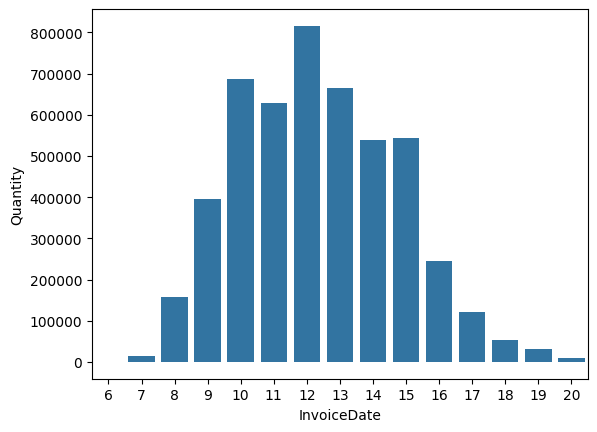

In [105]:
data_hour = data.groupby(data['InvoiceDate'].dt.hour)['Quantity'].sum()
data_hour = data_hour.to_frame()
sns.barplot(x= 'InvoiceDate',y='Quantity',data =  data_hour)

Видим что большинство количество заказов приходится именно на середину дня

Пытаемся предсказать, вернётся ли клиент и сделает ли покупку в следующем месяце
на основе его исторического поведения.

In [119]:
data = data.sort_values('InvoiceDate')
data = data[data['Quantity'] > 0]

In [125]:
train = data[(data['InvoiceDate'].dt.year == 2010) | ((data['InvoiceDate'].dt.year == 2011) & (data['InvoiceDate'].dt.month <= 10))]
train

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
...,...,...,...,...,...,...,...,...,...,...
431666,573695,23557,LANDMARK FRAME BAKER STREET,2,2011-10-31 17:13:00,12.50,15023.0,United Kingdom,25.00,10
431670,573695,23397,FOOT STOOL HOME SWEET HOME,4,2011-10-31 17:13:00,9.95,15023.0,United Kingdom,39.80,10
431663,573695,23558,LANDMARK FRAME LONDON BRIDGE,2,2011-10-31 17:13:00,12.50,15023.0,United Kingdom,25.00,10
431662,573695,23554,LANDMARK FRAME OXFORD STREET,1,2011-10-31 17:13:00,12.50,15023.0,United Kingdom,12.50,10


In [124]:
test = data[(data['InvoiceDate'].dt.year == 2011) & (data['InvoiceDate'].dt.month > 10)]
test

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month
431695,573744,84978,HANGING HEART JAR T-LIGHT HOLDER,36,2011-11-01 08:16:00,1.06,17733.0,United Kingdom,38.16,11
431681,573744,22578,WOODEN STAR CHRISTMAS SCANDINAVIAN,24,2011-11-01 08:16:00,0.29,17733.0,United Kingdom,6.96,11
431680,573744,22577,WOODEN HEART CHRISTMAS SCANDINAVIAN,24,2011-11-01 08:16:00,0.29,17733.0,United Kingdom,6.96,11
431679,573744,22340,NOEL GARLAND PAINTED ZINC,24,2011-11-01 08:16:00,0.39,17733.0,United Kingdom,9.36,11
431682,573744,22579,WOODEN TREE CHRISTMAS SCANDINAVIAN,24,2011-11-01 08:16:00,0.29,17733.0,United Kingdom,6.96,11
...,...,...,...,...,...,...,...,...,...,...
541903,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,12
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,12680.0,France,15.00,12
541894,581587,22631,CIRCUS PARADE LUNCH BOX,12,2011-12-09 12:50:00,1.95,12680.0,France,23.40,12


Разделили наш датасет на датасет на котором будет обучаться модель и на датасет на котором будет проверять модель

In [130]:
uploaded = files.upload()

Saving data_for_ml.csv to data_for_ml.csv


In [131]:
data_retail = pd.read_csv('data_for_ml.csv')

In [135]:
data_retail = data_retail.drop(0)


,customer_id,number_of_orders,revenue,mean_check,days_from_purchase,target
1,12346.0,1,77183.60,77183.600000,287,0
2,12347.0,6,4085.18,680.863333,1,0
3,12348.0,4,1797.24,449.310000,37,0
4,12350.0,1,334.40,334.400000,272,0
5,12352.0,7,2194.31,313.472857,34,1
...,...,...,...,...,...,...
3970,18280.0,1,180.60,180.600000,239,0
3971,18281.0,1,80.82,80.820000,142,0
3972,18282.0,1,100.21,100.210000,88,0
3973,18283.0,11,1235.32,112.301818,5,1


In [161]:
import numpy as np
X = data_retail[['number_of_orders','revenue','mean_check','days_from_purchase']]
X[['revenue','mean_check']] = np.log(1 + X[['revenue','mean_check']])
y = data_retail['target']
X

/tmp/ipython-input-2010678274.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['revenue','mean_check']] = np.log(1 + X[['revenue','mean_check']])


,number_of_orders,revenue,mean_check,days_from_purchase
0,1905,14.050484,6.499750,1
1,1,11.253955,11.253955,287
2,6,8.315366,6.524829,1
3,4,7.494564,6.109936,37
4,1,5.815324,5.815324,272
...,...,...,...,...
3970,1,5.201806,5.201806,239
3971,1,4.404522,4.404522,142
3972,1,4.617198,4.617198,88
3973,11,7.119895,4.730055,5


In [162]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size = 0.8)

In [163]:
from sklearn.linear_model import LogisticRegression


In [173]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [175]:
model = LogisticRegression()
model.fit(X_train_scaled,y_train)


LogisticRegression()

In [176]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay


In [177]:
from sklearn.preprocessing import StandardScaler

In [178]:
predict = model.predict(X_test_scaled)

In [179]:
roc_auc_score(y_test,predict)

np.float64(0.6727554179566564)

In [180]:
model.coef_

array([[ 2.50399892,  0.81595004, -0.3980118 , -0.28613639]])

«Baseline логистической регрессии после лог-преобразования денежных признаков и стандартизации достиг ROC-AUC ≈ 0.67.».

In [183]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.6 MB/s eta 0:00:00


In [184]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score


In [185]:
model_cb = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=False,
    random_state=42
)


In [189]:
model_cb.fit(X_train,y_train)

In [193]:
y_pred_cb = model_cb.predict_proba(X_test)[:, 1]

In [194]:
roc_auc_score(y_test, y_pred_cb)

np.float64(0.7174785001719987)

In [196]:


fi = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_cb.get_feature_importance()
}).sort_values(by='importance', ascending=False)

fi


,feature,importance
3,days_from_purchase,32.506770
1,revenue,23.155005
2,mean_check,22.817822
0,number_of_orders,21.520403


Использование градиентного бустинга (CatBoost) позволило улучшить качество модели по сравнению с линейным baseline. ROC-AUC вырос с ~0.64 до ~0.72, что свидетельствует о наличии нелинейных зависимостей в данных. Ключевым фактором возврата клиента остаётся давность последней покупки